# Installs and imports

In [114]:
#pip install pandas matplotlib numpy websockets sklearn

In [115]:
# Global imports for the game
import websockets
import json
import pandas as pd
import matplotlib.pyplot as plt
import backtest
import importlib
importlib.reload(backtest)

<module 'backtest' from 'c:\\Users\\nicol\\OneDrive - Hampton School\\AlgoSoc\\backtest.py'>

# Task 
### Instructions:
Use the train_data.csv to formulate a trading strategy to trade on assets A,B,C and D. The goal is to aim for the highest possible Sharpe ratio. Market-making and directional strategies (ones that make use of stat-arb/general prediction) are all valid strategies. We will also reward perfect market making - i.e. if you set your bid/ask as the true bid/ask for the next timestep you will be given a payout of spread * min size on bid or ask.

Some rules:
- Your code must pass the timeout constraint of 1 minute to evaluate on our test set
- You are only allowed to use the following libraries in your submission:
    - pandas
    - numpy
    - scikit-learn
- You can only submit one buy and one sell order per asset per timestep (or fewer)
- You can at most be exposed 100 shares of a given asset (i.e. max position is +-100)

In [116]:
# USERNAME (set this to your own)
USERNAME = "Nico_Alfonso"

In [117]:
# Global variables
SYMBOLS = ["A","B","C","D"]
URL = "ws://34.72.232.39:8765"

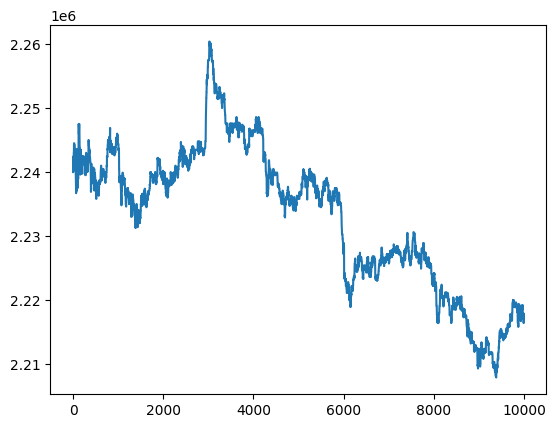

In [118]:
# Train data
train_data = pd.read_csv("train.csv", header=[0, 1], index_col=0)
plt.plot(train_data.iloc[:,0])

Definition of the orderbook:
```python
class Orderbook:
    def __init__(self):
        self.buy_orders: Dict[int, int] = {} # price : quantity
        self.sell_orders: Dict[int, int] = {} # price : quantity
```
        
Definition of a trade:
```python
class Trade:
    def __init__(self):
        self.price = None
        self.side = None
        self.quantity = None
```

Definition of an order:
```python
class Order:
    def __init__(self, symbol, price, side, quantity):
        self.symbol = symbol
        self.price = price
        self.side = side # 'buy' or 'sell'
        self.quantity = quantity
```

Definition of state:
```python
state = {
    "orderbook": Dict[str, Orderbook],
    "positions": Dict[str, int],
    "trades": Dict[str, Trade]
}
```

In [119]:
# Trader class
from extra_classes import Orderbook, Order, Trade
from typing import Dict, List
import numpy as np
from collections import defaultdict, deque

SYMBOLS = ["A", "B", "C", "D"]

#constants chosen based on experimentation with training data
bse_qty = 40
max_qty = 300
min_qty = 1

#set ewma values
ewma_alf_mid = 0.12 #mid price momentum trackr
ewma_alf_imb = 0.15 #order book imbalance tracker
ewma_alf_vol = 0.12 #mid price volatility tracker

#set inventory parameters
inv_limit = 900 #max inventory limit (just realised its already set to 100)
inv_pen = 0.0005 #inventory penalty factor

#set exploration rate for local minima
ran_rate = 0.02
np.random.seed(67) #for consistent results

class Trader:
    def __init__(self):
        # stateful ewmas
        _dict = {s: None for s in SYMBOLS}
        self.mid_ewma = _dict.copy()
        self.vol_ewma = _dict.copy()
        self.imb_ewma = _dict.copy()
        self.mom_ewma = _dict.copy()

        # last mid prices and history
        self.last_mid = _dict.copy()
        self.mid_hist = {s: deque(maxlen=6) for s in SYMBOLS}

    #ewma calculation
    def _ewma(self, store, key, value, alpha):
        if value is None:
            return store[key]   #if can't calc keep as is
        prev = store.get(key)
        if prev is None:
            store[key] = float(value) #initialise
        else:
            store[key] = alpha * float(value) + (1 - alpha) * float(prev) #formula
        return store[key]
    
    #get best prices from orderbook
    def _best_bid_ask(self, ob: Orderbook):
        try:
            if not ob.buy_orders or not ob.sell_orders:
                return None, None
            bp = max(ob.buy_orders.keys())
            ap = min(ob.sell_orders.keys())
            return (float(bp), ob.buy_orders[bp]), (float(ap), ob.sell_orders[ap]) #get best prices and volumes
        except:
            return None, None
    #microprice and orderbook imbalance
    def _microprice_imbalance(self, ob: Orderbook):
        try:
            bids = sorted([(float(p), int(q)) for p, q in ob.buy_orders.items()], key=lambda x: -x[0])[:5]
            asks = sorted([(float(p), int(q)) for p, q in ob.sell_orders.items()], key=lambda x: x[0])[:5]
            if not bids or not asks:
                return None, 0.0
            bp, bq = bids[0]
            ap, aq = asks[0]
            micro = (ap*bq + bp*aq) / (bq+aq)
            imb = ((sum(q for _,q in bids) - sum(q for _,q in asks)) / 
                   max(1, (sum(q for _,q in bids) + sum(q for _,q in asks))))
            return micro, imb
        except:
            return None, 0.0
        
    #confidence calculation
    def _confidence(self, imb, momentum):
        c = 0.0
        c += 0.5 * min(1.0, abs(imb)*2)
        c += 0.5 * min(1.0, abs(momentum)*1.5)
        return min(1.0, c)
    
    #quantity calculation based on confidence and inventory
    def _qty(self, base, conf, inv):
        inv_penalty = max(0.0, 1 - inv_pen * abs(inv))
        qty = base * (1 + 4*conf) * inv_penalty
        return int(min(max_qty, max(min_qty, qty)))

    # Main trading loop
    def run(self, state):
        orders : List[Order]= []
        orderbook : Dict[str, Orderbook] = state["orderbook"]
        positions : Dict[str, int] = state["positions"]
        trades : Dict[str, List[Trade]] = state["trades"]

        for s in SYMBOLS:
            ob = orderbook.get(s, Orderbook())
            best_bid, best_ask = self._best_bid_ask(ob)
            if not best_bid or not best_ask:
                continue

            bp, bq = best_bid
            ap, aq = best_ask

            mid = (bp + ap) / 2
            micro, imb = self._microprice_imbalance(ob)

            #update momentum + vol ewma
            prev_mid = self.last_mid.get(s)
            if prev_mid is not None:
                delta = mid - prev_mid
                self._ewma(self.mom_ewma, s, delta, ewma_alf_mid)
                self._ewma(self.vol_ewma, s, abs(delta), ewma_alf_vol)

            self._ewma(self.imb_ewma, s, imb, ewma_alf_imb)
            self.last_mid[s] = mid

            momentum = self.mom_ewma.get(s) or 0.0
            inv = positions.get(s, 0)
            conf = self._confidence(imb, momentum)
            qty = self._qty(bse_qty, conf, inv)

            #radnom explore (small chance to be slightly more aggressive)
            if np.random.rand() < ran_rate:
                qty = min(max_qty, qty * 2)

            # inventory risk control
            allow_buy  = inv + qty <  inv_limit
            allow_sell = inv - qty > -inv_limit

            
            if allow_buy:
                orders.append(Order(s, bp, "buy", qty))
            if allow_sell:
                orders.append(Order(s, ap, "sell", qty))

            # soft inventory flattening
            if inv > 0:   # if long sell
                flatten = max(1, inv // 20)
                orders.append(Order(s, bp, "sell", flatten))
            elif inv < 0: # if short buy
                flatten = max(1, (-inv) // 20)
                orders.append(Order(s, ap, "buy", flatten))

        return orders


In [120]:
# This is a backtesting cell on the train set. 
# Run it before submitting to check for errors and how long it takes to run your code.
# If it falls under a minute then you are safe to submit.

# Remember to rerun the trader cell before running the submission cell.
backtest.evaluate(Trader())

'Final test PnL: 193145950.0'

In [121]:
# Submission cell 
""" INSTRUCTIONS:
To submit, run the cell with your "Trader class" code AND THEN this block in that order. 

The way this block works is that it uses ipython's environment variable _i to 
get access to the code as a string so that it can be sent 
to the virtual machine and run to instantiate your custom Trader logic.
The code will fail otherwise.
"""

async with websockets.connect(URL) as ws:
    await ws.send(json.dumps({"user": USERNAME,"code": _i}))
    message = await ws.recv()
    async for msg in ws:
        print("Received:", msg)
        msg = json.loads(msg)
        if isinstance(msg, list):
            msg = msg[0]
        if msg["result"]:
            break

TimeoutError: timed out during opening handshake